In [29]:
import pandas as pd
import numpy as np
import uuid
from datetime import datetime, timedelta
import random

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

# Number of records
n = 500

# Helper function to generate random dates
def random_date(start, end, n):
    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)
    diff = (end_ts - start_ts).days
    random_days = np.random.randint(0, diff, n)
    return [start_ts + timedelta(days=int(d)) for d in random_days]

# Generate each column
record_ids = [str(uuid.uuid4()) for _ in range(n)]

age_group_choices = ["18-25", "26-35", "36-45", "46-60", "60+"]
age_group = np.random.choice(age_group_choices, n, p=[0.15, 0.25, 0.25, 0.20, 0.15])

# Generate age consistent with age_group
def age_from_group(group):
    ranges = {
        "18-25": (18, 25),
        "26-35": (26, 35),
        "36-45": (36, 45),
        "46-60": (46, 60),
        "60+":   (61, 80)
    }
    lo, hi = ranges[group]
    return random.randint(lo, hi)

age = [age_from_group(g) for g in age_group]

weight = np.random.randint(45, 120, n)  # kg

gender = np.random.choice(["Male", "Female", "Other"], n, p=[0.48, 0.48, 0.04])

region = np.random.choice(["North", "South", "East", "West"], n)

smoking_status = np.random.choice(
    ["Smoker", "Non-Smoker", "Former Smoker"], n, p=[0.30, 0.50, 0.20]
)

exercise_frequency = np.random.choice(
    ["Daily", "Weekly", "Rarely", "Never"], n, p=[0.20, 0.35, 0.30, 0.15]
)

# BMI calculated realistically
height_m = np.random.uniform(1.50, 1.90, n)  # meters
bmi = np.round(weight / (height_m ** 2), 2)

blood_pressure = np.round(np.random.normal(120, 15, n), 1)
blood_pressure = np.clip(blood_pressure, 80, 200)

cholesterol_level = np.round(np.random.normal(200, 35, n), 1)
cholesterol_level = np.clip(cholesterol_level, 100, 350)

glucose_level = np.round(np.random.normal(100, 25, n), 1)
glucose_level = np.clip(glucose_level, 60, 300)

# Diabetes influenced by glucose & bmi
diabetes_prob = []
for i in range(n):
    prob = 0.1
    if glucose_level[i] > 125:
        prob += 0.40
    if bmi[i] > 30:
        prob += 0.20
    if smoking_status[i] == "Smoker":
        prob += 0.10
    if age[i] > 45:
        prob += 0.15
    diabetes_prob.append(min(prob, 0.95))

diabetes = [np.random.rand() < p for p in diabetes_prob]

# Hypertension influenced by blood pressure & bmi
hypertension_prob = []
for i in range(n):
    prob = 0.1
    if blood_pressure[i] > 130:
        prob += 0.40
    if bmi[i] > 28:
        prob += 0.15
    if smoking_status[i] == "Smoker":
        prob += 0.10
    if age[i] > 40:
        prob += 0.15
    hypertension_prob.append(min(prob, 0.95))

hypertension = [np.random.rand() < p for p in hypertension_prob]

visit_date = random_date("2022-01-01", "2024-12-31", n)

# Build DataFrame
df = pd.DataFrame({
    "record_id":         record_ids,
    "age_group":         age_group,
    "age":               age,
    "weight":            weight,
    "gender":            gender,
    "region":            region,
    "smoking_status":    smoking_status,
    "exercise_frequency":exercise_frequency,
    "bmi":               bmi,
    "blood_pressure":    blood_pressure,
    "diabetes":          diabetes,
    "hypertension":      hypertension,
    "cholesterol_level": cholesterol_level,
    "glucose_level":     glucose_level,
    "visit_date":        visit_date
})

# Save to CSV
df.to_csv("health_records.csv", index=False)

print("✅ Dataset Created Successfully!")
print(f"📊 Shape: {df.shape}")
print(f"\n🔍 First 5 Rows:")
print(df.head())
print(f"\n📈 Basic Info:")
print(df.dtypes)
print(f"\n✅ Diabetes Cases: {sum(diabetes)} / {n}")
print(f"✅ Hypertension Cases: {sum(hypertension)} / {n}")

✅ Dataset Created Successfully!
📊 Shape: (500, 15)

🔍 First 5 Rows:
                              record_id age_group  age  weight  gender region  \
0  48219114-ed61-4fa9-8654-d6c5889be5bc     26-35   27     107  Female   West   
1  4ef3d0b7-5964-4775-ac86-c2b57c6d7bd1       60+   61      61    Male  South   
2  a76a6883-964a-4f58-8422-305c9fc1231e     46-60   57     117  Female  South   
3  4f10fa01-1150-4e98-9111-c33136a112ff     36-45   40      77    Male  South   
4  26255640-833b-4faa-9b56-89131651192c     26-35   29      73  Female  North   

  smoking_status exercise_frequency    bmi  blood_pressure  diabetes  \
0         Smoker             Rarely  34.58           125.9     False   
1     Non-Smoker             Rarely  18.45           100.3      True   
2     Non-Smoker             Rarely  36.05           108.0      True   
3     Non-Smoker             Rarely  33.58            83.5     False   
4     Non-Smoker             Weekly  26.56           134.7     False   

   hypertens

<h1>Part-B</h1>

<h3>1</h3>

Hypothesis 1

$H_0$: Smoking status and diabetes occurrence are independent.

$H_1$: Smoking status and diabetes occurrence are dependent.

Hypothesis 2

$H_0$: The mean glucose level is the same for all age groups.

$H_1$: At least one age group has a different mean glucose level.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

In [31]:
df = pd.read_csv("health_records.csv")
df.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,48219114-ed61-4fa9-8654-d6c5889be5bc,26-35,27,107,Female,West,Smoker,Rarely,34.58,125.9,False,False,240.3,110.1,2024-09-18
1,4ef3d0b7-5964-4775-ac86-c2b57c6d7bd1,60+,61,61,Male,South,Non-Smoker,Rarely,18.45,100.3,True,False,263.8,66.3,2024-10-06
2,a76a6883-964a-4f58-8422-305c9fc1231e,46-60,57,117,Female,South,Non-Smoker,Rarely,36.05,108.0,True,True,143.9,91.8,2024-03-14
3,4f10fa01-1150-4e98-9111-c33136a112ff,36-45,40,77,Male,South,Non-Smoker,Rarely,33.58,83.5,False,True,157.5,81.2,2024-04-10
4,26255640-833b-4faa-9b56-89131651192c,26-35,29,73,Female,North,Non-Smoker,Weekly,26.56,134.7,False,False,201.5,91.9,2022-08-02


In [32]:
print("Shape of Dataset:", df.shape)
df.info()

Shape of Dataset: (500, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           500 non-null    object 
 1   age_group           500 non-null    object 
 2   age                 500 non-null    int64  
 3   weight              500 non-null    int64  
 4   gender              500 non-null    object 
 5   region              500 non-null    object 
 6   smoking_status      500 non-null    object 
 7   exercise_frequency  500 non-null    object 
 8   bmi                 500 non-null    float64
 9   blood_pressure      500 non-null    float64
 10  diabetes            500 non-null    bool   
 11  hypertension        500 non-null    bool   
 12  cholesterol_level   500 non-null    float64
 13  glucose_level       500 non-null    float64
 14  visit_date          500 non-null    object 
dtypes: bool(2), float64(4), int64

In [33]:
df.describe()

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,41.794000,81.448000,28.381400,120.95920,197.109600,102.587800
std,16.628427,22.205167,8.831883,15.08228,34.926751,23.934948
min,18.000000,45.000000,12.920000,80.00000,100.000000,60.000000
25%,28.000000,62.000000,20.820000,110.47500,174.775000,85.375000
50%,39.000000,81.000000,27.885000,121.40000,197.550000,101.100000
75%,53.000000,100.000000,34.565000,130.90000,218.850000,118.625000
max,80.000000,119.000000,51.070000,166.80000,296.300000,191.400000


In [34]:
df.isnull().sum()

record_id             0
age_group             0
age                   0
weight                0
gender                0
region                0
smoking_status        0
exercise_frequency    0
bmi                   0
blood_pressure        0
diabetes              0
hypertension          0
cholesterol_level     0
glucose_level         0
visit_date            0
dtype: int64

In [35]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


<h3>2</h3>

In [36]:
columns = ['age', 'weight', 'bmi', 'blood_pressure',
           'cholesterol_level', 'glucose_level']

confidence = 0.95

for col in columns:

    mean = df[col].mean()
    std = df[col].std()
    n = len(df[col])

    se = std / np.sqrt(n)

    margin_error = stats.t.ppf((1 + confidence) / 2, n - 1) * se

    lower = mean - margin_error
    upper = mean + margin_error

    print("\n", col.upper())
    print("Mean :", round(mean,2))
    print("Confidence Interval : ({:.2f}, {:.2f})".format(lower, upper))


 AGE
Mean : 41.79
Confidence Interval : (40.33, 43.26)

 WEIGHT
Mean : 81.45
Confidence Interval : (79.50, 83.40)

 BMI
Mean : 28.38
Confidence Interval : (27.61, 29.16)

 BLOOD_PRESSURE
Mean : 120.96
Confidence Interval : (119.63, 122.28)

 CHOLESTEROL_LEVEL
Mean : 197.11
Confidence Interval : (194.04, 200.18)

 GLUCOSE_LEVEL
Mean : 102.59
Confidence Interval : (100.48, 104.69)


The confidence interval gives the range in which the true population mean is expected to lie with 95% confidence. Narrow intervals indicate more reliable estimates.

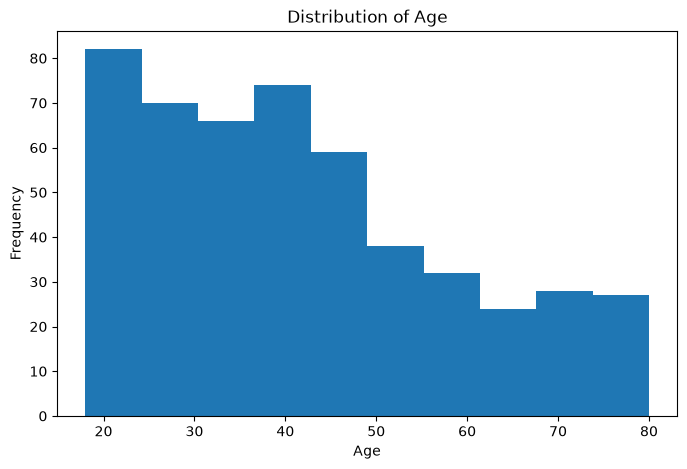

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=10)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

<h3>4</h3>

In [38]:
diabetic = df[df["diabetes"] == True]["bmi"]

non_diabetic = df[df["diabetes"] == False]["bmi"]

t_statistic, p_value = stats.ttest_ind(diabetic, non_diabetic)

print("T-Statistic :", round(t_statistic,4))
print("P-value :", round(p_value,4))

T-Statistic : 3.4621
P-value : 0.0006


In [39]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")

Reject the Null Hypothesis (H₀)


If H₀ is rejected

Since the p-value is less than 0.05, the null hypothesis is rejected. This indicates a significant difference in the mean BMI between diabetic and non-diabetic individuals.

If H₀ is not rejected

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates no significant difference in the mean BMI between diabetic and non-diabetic individuals.

<Figure size 800x500 with 0 Axes>

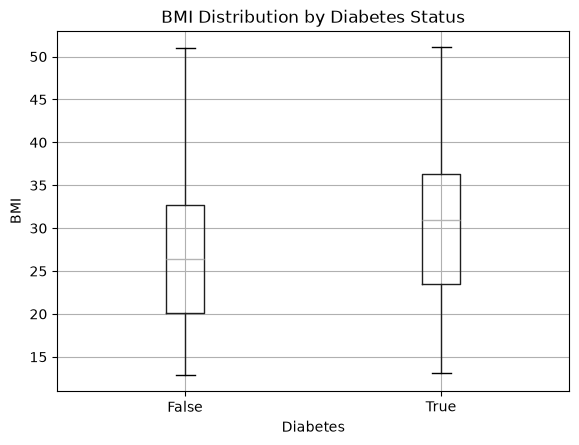

In [40]:
plt.figure(figsize=(8,5))

df.boxplot(column="bmi", by="diabetes")

plt.title("BMI Distribution by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes")
plt.ylabel("BMI")

plt.show()

<h3>5</h3>

In [41]:
observed = pd.crosstab(df["smoking_status"], df["diabetes"]).values

row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
grand_total = observed.sum()

expected = np.outer(row_totals, col_totals) / grand_total

chi_square_stat = ((observed - expected) ** 2 / expected).sum()

r, c = observed.shape
dfree = (r - 1) * (c - 1)

alpha = 0.05

p_value = 1 - stats.chi2.cdf(chi_square_stat, dfree)
critical_value = stats.chi2.ppf(1 - alpha, dfree)


if chi_square_stat > critical_value:
    decision = "Reject H0 (Variables are related)"
else:
    decision = "Fail to Reject H0 (Variables are independent)"

print("Observed Table:\n", observed)
print("\nExpected Table:\n", expected)

print("\nChi-Square Statistic:", round(chi_square_stat, 4))
print("Degrees of Freedom:", dfree)
print("p-value:", round(p_value, 4))
print("Critical Value:", round(critical_value, 4))
print("Decision:", decision)

Observed Table:
 [[ 52  39]
 [173  76]
 [100  60]]

Expected Table:
 [[ 59.15  31.85]
 [161.85  87.15]
 [104.    56.  ]]

Chi-Square Statistic: 5.1036
Degrees of Freedom: 2
p-value: 0.0779
Critical Value: 5.9915
Decision: Fail to Reject H0 (Variables are independent)


If the decision is "Reject H₀":

Since the Chi-Square statistic is greater than the critical value, the null hypothesis is rejected. This indicates that smoking status and diabetes occurrence are significantly associated.

If the decision is "Fail to Reject H₀":

Since the Chi-Square statistic is less than the critical value, we fail to reject the null hypothesis. This indicates that smoking status and diabetes occurrence are independent.

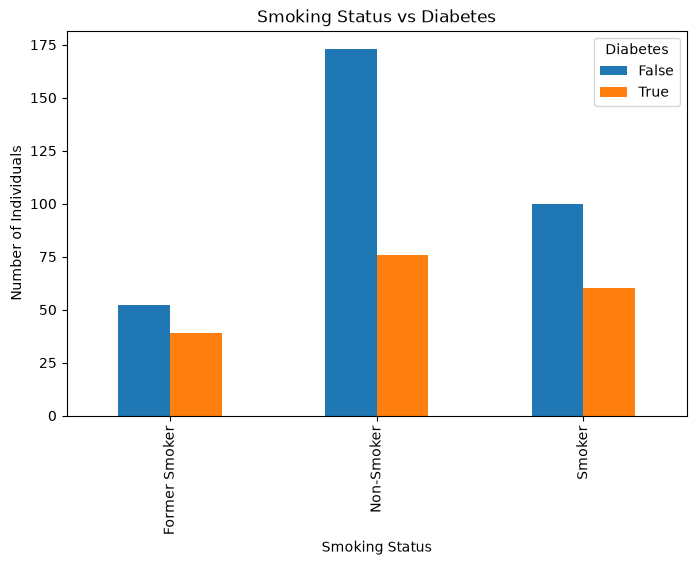

In [42]:
chi_data = pd.crosstab(df["smoking_status"], df["diabetes"])
chi_data.plot(kind="bar", figsize=(8,5))

plt.title("Smoking Status vs Diabetes")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Individuals")
plt.legend(title="Diabetes")

plt.show()

<h3>6</h3>

In [43]:
group1 = df[df["age_group"] == "18-25"]["glucose_level"]
group2 = df[df["age_group"] == "26-35"]["glucose_level"]
group3 = df[df["age_group"] == "36-45"]["glucose_level"]
group4 = df[df["age_group"] == "46-60"]["glucose_level"]
group5 = df[df["age_group"] == "60+"]["glucose_level"]

f_statistic, p_value = stats.f_oneway(group1, group2, group3, group4, group5)

alpha = 0.05

if p_value < alpha:
    decision = "Reject H0"
else:
    decision = "Fail to Reject H0"

print("F-Statistic :", round(f_statistic, 4))
print("P-value :", round(p_value, 4))
print("Decision :", decision)

F-Statistic : 2.2061
P-value : 0.0673
Decision : Fail to Reject H0


If H₀ is rejected:

Since the p-value is less than 0.05, the null hypothesis is rejected. This indicates that at least one age group has a significantly different mean glucose level.

If H₀ is not rejected:

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that the mean glucose level does not differ significantly among the age groups.

<Figure size 800x500 with 0 Axes>

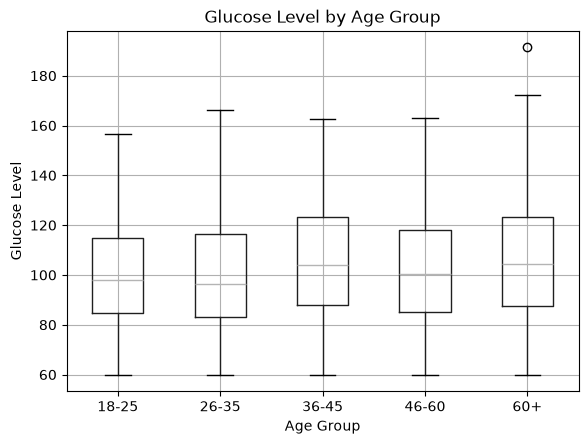

In [44]:
plt.figure(figsize=(8,5))

df.boxplot(column="glucose_level", by="age_group")

plt.title("Glucose Level by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Glucose Level")

plt.show()

<h3>7</h3>

In [45]:
covariance_matrix = np.cov(df["age"], df["bmi"])

correlation_matrix = np.corrcoef(df["age"], df["bmi"])

print("Covariance Matrix")
print(covariance_matrix)

print("\nCorrelation Matrix")
print(correlation_matrix)

print("\nCovariance :", round(covariance_matrix[0,1], 4))
print("Correlation :", round(correlation_matrix[0,1], 4))

Covariance Matrix
[[276.50457315   4.78842525]
 [  4.78842525  78.00216277]]

Correlation Matrix
[[1.        0.0326053]
 [0.0326053 1.       ]]

Covariance : 4.7884
Correlation : 0.0326


If correlation is positive

The covariance is positive, indicating that age and BMI tend to increase together. The positive correlation suggests a positive linear relationship between the two variables.

If correlation is negative

The covariance is negative, indicating that as age increases, BMI tends to decrease. The negative correlation suggests an inverse linear relationship between the two variables.

If correlation is close to 0

The correlation value is close to zero, indicating a very weak or no linear relationship between age and BMI.

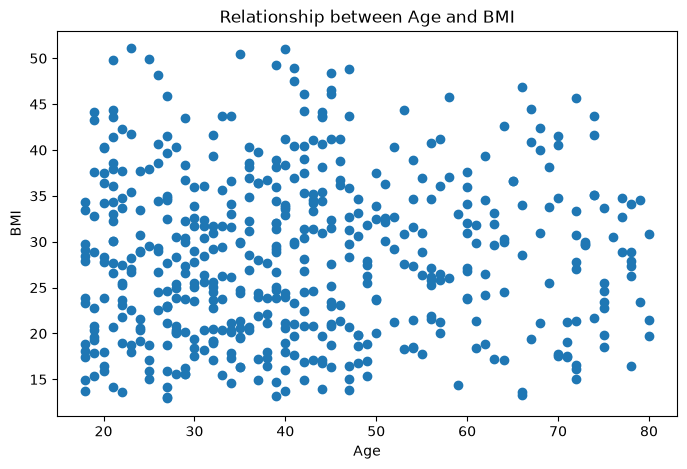

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["age"], df["bmi"])

plt.title("Relationship between Age and BMI")
plt.xlabel("Age")
plt.ylabel("BMI")

plt.show()

<h3>8</h3>

# Result and Interpretation

| Statistical Test | Decision | Interpretation |
|------------------|----------|----------------|
| Independent t-Test | Reject H₀ | There is a significant difference in the mean BMI between diabetic and non-diabetic individuals. |
| Chi-Square Test | Fail to Reject H₀ | Smoking status and diabetes occurrence are independent. |
| One-Way ANOVA | Fail to Reject H₀ | There is no significant difference in the mean glucose level among the age groups. |